# Strategy Comparison Backtest

This notebook runs the downstream portfolio backtest for the project.

It compares the model-based strategies from HMM and MS-VAR against the project benchmarks:

- 60/40 equity-bond portfolio
- Equal-weight equity-bond-gold portfolio
- Buy-and-hold equity portfolio

The notebook starts after the model notebooks have already produced target portfolio weights. It does not estimate HMM or MS-VAR directly.

## Backtest Design

The model notebooks export monthly target weights after regime classification and regime-to-asset mapping.

Expected input files:

- outputs/tables/hmm_target_weights.csv
- outputs/tables/msvar_target_weights.csv

Current exported columns:

Date
Regime
Equity
Bonds
Gold

This notebook renames those columns internally to match the asset-return columns in market_clean.csv:

Regime -> regime_label
Equity -> index_fund
Bonds -> treasury_fund
Gold -> gold_fund

The main evaluation is restricted to the test period. Based on the current train-test split, the HMM test signal period starts on 2018-10-31 and the MS-VAR test signal period starts on 2018-11-30.

For HMM and MS-VAR, exported weights are treated as signal-date target weights. This notebook applies a one-month lag before calculating returns, so weights generated for month t are applied to the following month’s close-to-close return.

Benchmarks are evaluated over the same realized-return test window as the model strategies.

## Cost and Tax Treatment

The main comparison uses net returns after transaction costs.

Transaction costs are modeled as monthly rebalancing costs. At each rebalance, total traded notional is measured as the sum of absolute differences between drifted weights and target weights. A transaction cost of 10 basis points is applied to that traded notional.

Tax results are reported separately as sensitivity scenarios. They are not treated as the base-case performance result because actual taxes depend on investor type, account structure, holding period, jurisdiction, and the specific investment vehicle. The tax calculation here is an approximation, not a full tax-lot accounting model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data")
OUTPUT_TABLES_DIR = Path("../outputs/tables")
OUTPUT_FIGURES_DIR = Path("../outputs/figures")

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ASSET_COLS = ["index_fund", "treasury_fund", "gold_fund"]

TRANSACTION_COST_BPS = 10

MODEL_SIGNAL_START_DATES = {
    "HMM": pd.Timestamp("2018-10-31"),
    "MSVAR": pd.Timestamp("2018-11-30"),
}

ASSET_TAX_RATES = {
    "No Tax": {
        "index_fund": 0.00,
        "treasury_fund": 0.00,
        "gold_fund": 0.00,
    },
    "Long-Term Capital Gain Sensitivity": {
        "index_fund": 0.15,
        "treasury_fund": 0.15,
        "gold_fund": 0.15,
    },
    "Gold Collectibles Sensitivity": {
        "index_fund": 0.15,
        "treasury_fund": 0.15,
        "gold_fund": 0.28,
    },
    "High Short-Term Sensitivity": {
        "index_fund": 0.35,
        "treasury_fund": 0.35,
        "gold_fund": 0.35,
    },
}

In [2]:
asset_returns = pd.read_csv(
    DATA_DIR / "market_clean.csv",
    parse_dates=["Date"]
).set_index("Date")

asset_returns = asset_returns[ASSET_COLS].sort_index()

print(asset_returns.shape)
print(f"Asset return range: {asset_returns.index.min().date()} to {asset_returns.index.max().date()}")

asset_returns.head()

(431, 3)
Asset return range: 1990-02-28 to 2025-12-31


,index_fund,treasury_fund,gold_fund
Date,,,
1990-02-28,0.012748,-0.003267,0.017748
1990-03-31,0.027663,-0.003589,-0.051637
1990-04-30,-0.025015,-0.027230,-0.001374
1990-05-31,0.096928,0.044975,-0.013624
1990-06-30,-0.006555,0.022940,-0.003990


In [3]:
def load_target_weights(path):
    """
    Load target weights exported by the model notebooks and standardize column names.

    Current upstream format:
    Date, Regime, Equity, Bonds, Gold

    Standardized format used here:
    Date index, regime_label, index_fund, treasury_fund, gold_fund
    """
    weights = pd.read_csv(path, parse_dates=["Date"])

    rename_map = {
        "Regime": "regime_label",
        "Equity": "index_fund",
        "Bonds": "treasury_fund",
        "Gold": "gold_fund",
    }

    weights = weights.rename(columns=rename_map)
    weights = weights.set_index("Date").sort_index()

    # Convert percentages to decimals if needed.
    if all(col in weights.columns for col in ASSET_COLS):
        median_weight_sum = weights[ASSET_COLS].sum(axis=1).median()
        if np.isclose(median_weight_sum, 100.0, atol=1e-6):
            weights[ASSET_COLS] = weights[ASSET_COLS] / 100.0

    return weights


model_weight_files = {
    "HMM": OUTPUT_TABLES_DIR / "hmm_target_weights.csv",
    "MSVAR": OUTPUT_TABLES_DIR / "msvar_target_weights.csv",
}

model_weights = {}

for model_name, path in model_weight_files.items():
    if path.exists():
        weights = load_target_weights(path)
        model_weights[model_name] = weights
        print(f"Loaded {model_name} target weights from {path}")
        display(weights.head())
    else:
        print(f"Missing {model_name} target weights: {path}")

print(f"\nAvailable model weight files: {len(model_weights)}")

Loaded HMM target weights from ..\outputs\tables\hmm_target_weights.csv


,regime_label,index_fund,treasury_fund,gold_fund
Date,,,,
1990-02-28,0,0.304427,0.448602,0.246971
1990-03-31,0,0.304427,0.448602,0.246971
1990-04-30,0,0.304427,0.448602,0.246971
1990-05-31,0,0.304427,0.448602,0.246971
1990-06-30,0,0.304427,0.448602,0.246971


Loaded MSVAR target weights from ..\outputs\tables\msvar_target_weights.csv


,regime_label,index_fund,treasury_fund,gold_fund
Date,,,,
1990-03-31,0,0.317679,0.328343,0.353978
1990-04-30,0,0.317679,0.328343,0.353978
1990-05-31,0,0.317679,0.328343,0.353978
1990-06-30,0,0.317679,0.328343,0.353978
1990-07-31,0,0.317679,0.328343,0.353978



Available model weight files: 2


In [4]:
def validate_target_weights(weights, asset_cols=ASSET_COLS):
    required_cols = ["regime_label"] + asset_cols
    missing_cols = [col for col in required_cols if col not in weights.columns]

    if missing_cols:
        raise ValueError(f"Missing required columns after renaming: {missing_cols}")

    if weights[asset_cols].isna().any().any():
        raise ValueError("Target weights contain missing values.")

    weight_sums = weights[asset_cols].sum(axis=1)

    if not np.allclose(weight_sums, 1.0, atol=1e-6):
        bad_rows = weights.loc[~np.isclose(weight_sums, 1.0, atol=1e-6)]
        raise ValueError(
            "Some target-weight rows do not sum to 1. "
            f"Example rows:\n{bad_rows.head()}"
        )

    if (weights[asset_cols] < -1e-6).any().any():
        bad_rows = weights.loc[(weights[asset_cols] < -1e-6).any(axis=1)]
        raise ValueError(
            "Some target weights are negative. "
            f"Example rows:\n{bad_rows.head()}"
        )

    return True


for model_name, weights in model_weights.items():
    validate_target_weights(weights)
    print(f"{model_name} target weights passed validation.")

if len(model_weights) == 0:
    raise FileNotFoundError(
        "No model target-weight files were found. "
        "Please make sure hmm_target_weights.csv and/or msvar_target_weights.csv "
        "exist in outputs/tables before running this notebook."
    )

HMM target weights passed validation.
MSVAR target weights passed validation.


## Benchmarks

The project benchmarks are constructed inside this notebook so that all strategies are evaluated under the same return and transaction-cost assumptions.

Benchmarks:

1. 60/40 equity-bond portfolio, monthly rebalanced
2. Equal-weight portfolio across equity, bonds, and gold, monthly rebalanced
3. Buy-and-hold equity portfolio

In [5]:
def build_constant_weights(index, equity_weight, bond_weight, gold_weight, regime_label):
    return pd.DataFrame(
        {
            "regime_label": regime_label,
            "index_fund": equity_weight,
            "treasury_fund": bond_weight,
            "gold_fund": gold_weight,
        },
        index=index,
    )


benchmark_weights = {
    "60_40": build_constant_weights(
        asset_returns.index,
        equity_weight=0.60,
        bond_weight=0.40,
        gold_weight=0.00,
        regime_label="60_40",
    ),
    "Equal_Weight": build_constant_weights(
        asset_returns.index,
        equity_weight=1 / 3,
        bond_weight=1 / 3,
        gold_weight=1 / 3,
        regime_label="Equal_Weight",
    ),
    "Buy_Hold_Equity": build_constant_weights(
        asset_returns.index,
        equity_weight=1.00,
        bond_weight=0.00,
        gold_weight=0.00,
        regime_label="Buy_Hold_Equity",
    ),
}

list(benchmark_weights.keys())

['60_40', 'Equal_Weight', 'Buy_Hold_Equity']

## Backtest Function

For HMM and MS-VAR, the notebook applies a one-month lag to target weights. For benchmarks, weights are applied directly because they are not generated by model signals.

Transaction costs are based on traded notional:

trade_notional = sum(abs(target_weights - drifted_weights))

One-way turnover is reported as half of traded notional.

Initial portfolio setup cost is excluded. After all strategies are backtested, they are aligned to the same realized-return test window before comparison.

In [6]:
def backtest_with_transaction_costs(
    target_weights,
    asset_returns,
    transaction_cost_bps=10,
    apply_signal_lag=True,
    include_initial_trade_cost=False,
):
    weights = target_weights[ASSET_COLS].copy()
    returns = asset_returns[ASSET_COLS].copy()

    if apply_signal_lag:
        weights = weights.shift(1)

    weights = weights.dropna()

    common_index = weights.index.intersection(returns.index)
    weights = weights.loc[common_index]
    returns = returns.loc[common_index]

    records = []
    previous_target = weights.iloc[0]

    for i, date in enumerate(common_index):
        current_target = weights.loc[date]
        current_returns = returns.loc[date]

        if i == 0:
            if include_initial_trade_cost:
                trade_notional = current_target.abs().sum()
            else:
                trade_notional = 0.0
        else:
            previous_returns = returns.loc[common_index[i - 1]]

            drifted_weights = previous_target * (1 + previous_returns)
            drifted_weights = drifted_weights / drifted_weights.sum()

            trade_notional = (current_target - drifted_weights).abs().sum()

        transaction_cost = trade_notional * transaction_cost_bps / 10000

        gross_return = (current_target * current_returns).sum()
        net_return = gross_return - transaction_cost

        records.append({
            "Date": date,
            "gross_return": gross_return,
            "net_return_after_costs": net_return,
            "trade_notional": trade_notional,
            "one_way_turnover": trade_notional / 2,
            "transaction_cost": transaction_cost,
            "index_fund_weight": current_target["index_fund"],
            "treasury_fund_weight": current_target["treasury_fund"],
            "gold_fund_weight": current_target["gold_fund"],
        })

        previous_target = current_target

    return pd.DataFrame(records).set_index("Date")

In [7]:
# Restrict model target weights to the test signal periods.
model_weights_test = {}

for model_name, weights in model_weights.items():
    if model_name not in MODEL_SIGNAL_START_DATES:
        raise ValueError(f"No test signal start date defined for {model_name}")

    signal_start = MODEL_SIGNAL_START_DATES[model_name]
    model_weights_test[model_name] = weights.loc[weights.index >= signal_start].copy()

    print(
        f"{model_name} signal test period starts at {signal_start.date()} "
        f"with {len(model_weights_test[model_name])} signal observations."
    )

# Benchmarks do not have signal start dates.
# They are created over the full asset-return index and later aligned to the same test window.
all_target_weights = {}
all_target_weights.update(model_weights_test)
all_target_weights.update(benchmark_weights)

cost_results_raw = {}

for strategy_name, weights in all_target_weights.items():
    is_model_strategy = strategy_name in model_weights_test

    result = backtest_with_transaction_costs(
        target_weights=weights,
        asset_returns=asset_returns,
        transaction_cost_bps=TRANSACTION_COST_BPS,
        apply_signal_lag=is_model_strategy,
        include_initial_trade_cost=False,
    )

    cost_results_raw[strategy_name] = result

# Align all strategies to the same realized-return comparison period.
common_result_index = None

for result in cost_results_raw.values():
    if common_result_index is None:
        common_result_index = result.index
    else:
        common_result_index = common_result_index.intersection(result.index)

cost_results = {
    strategy_name: result.loc[common_result_index].copy()
    for strategy_name, result in cost_results_raw.items()
}

# Exclude initial setup cost from the first common return observation for every strategy.
# This keeps the comparison window consistent.
for strategy_name, result in cost_results.items():
    first_date = result.index[0]
    result.loc[first_date, "trade_notional"] = 0.0
    result.loc[first_date, "one_way_turnover"] = 0.0
    result.loc[first_date, "transaction_cost"] = 0.0
    result.loc[first_date, "net_return_after_costs"] = result.loc[first_date, "gross_return"]

# Save aligned monthly results.
for strategy_name, result in cost_results.items():
    output_path = OUTPUT_TABLES_DIR / f"{strategy_name.lower()}_monthly_returns_with_costs.csv"
    result.to_csv(output_path)

    print(f"Saved {strategy_name} monthly returns with costs to {output_path}")
    print(f"{strategy_name}: {result.index.min().date()} to {result.index.max().date()}, {len(result)} months")

test_period_info = pd.DataFrame({
    "Strategy": list(cost_results.keys()),
    "Signal Start Date": [
        MODEL_SIGNAL_START_DATES.get(strategy_name, pd.NaT)
        for strategy_name in cost_results.keys()
    ],
    "Realized Return Start Date": [
        cost_results[strategy_name].index.min()
        for strategy_name in cost_results.keys()
    ],
    "Realized Return End Date": [
        cost_results[strategy_name].index.max()
        for strategy_name in cost_results.keys()
    ],
    "Number of Return Observations": [
        len(cost_results[strategy_name])
        for strategy_name in cost_results.keys()
    ],
})

test_period_info.to_csv(
    OUTPUT_TABLES_DIR / "test_period_info.csv",
    index=False
)

print("\nCompleted strategies:")
print(list(cost_results.keys()))

test_period_info

HMM signal test period starts at 2018-10-31 with 87 signal observations.
MSVAR signal test period starts at 2018-11-30 with 86 signal observations.
Saved HMM monthly returns with costs to ..\outputs\tables\hmm_monthly_returns_with_costs.csv
HMM: 2018-12-31 to 2025-12-31, 85 months
Saved MSVAR monthly returns with costs to ..\outputs\tables\msvar_monthly_returns_with_costs.csv
MSVAR: 2018-12-31 to 2025-12-31, 85 months
Saved 60_40 monthly returns with costs to ..\outputs\tables\60_40_monthly_returns_with_costs.csv
60_40: 2018-12-31 to 2025-12-31, 85 months
Saved Equal_Weight monthly returns with costs to ..\outputs\tables\equal_weight_monthly_returns_with_costs.csv
Equal_Weight: 2018-12-31 to 2025-12-31, 85 months
Saved Buy_Hold_Equity monthly returns with costs to ..\outputs\tables\buy_hold_equity_monthly_returns_with_costs.csv
Buy_Hold_Equity: 2018-12-31 to 2025-12-31, 85 months

Completed strategies:
['HMM', 'MSVAR', '60_40', 'Equal_Weight', 'Buy_Hold_Equity']


,Strategy,Signal Start Date,Realized Return Start Date,Realized Return End Date,Number of Return Observations
0,HMM,2018-10-31,2018-12-31,2025-12-31,85
1,MSVAR,2018-11-30,2018-12-31,2025-12-31,85
2,60_40,NaT,2018-12-31,2025-12-31,85
3,Equal_Weight,NaT,2018-12-31,2025-12-31,85
4,Buy_Hold_Equity,NaT,2018-12-31,2025-12-31,85


## Performance Metrics

The main strategy comparison uses net returns after transaction costs. This is the primary table for comparing HMM, MS-VAR, and the benchmarks over the common test period.

In [8]:
def annualized_return(monthly_returns):
    return (1 + monthly_returns).prod() ** (12 / len(monthly_returns)) - 1


def annualized_volatility(monthly_returns):
    return monthly_returns.std() * np.sqrt(12)


def sharpe_ratio(monthly_returns, risk_free_rate=0.0):
    excess_returns = monthly_returns - risk_free_rate / 12

    if excess_returns.std() == 0:
        return np.nan

    return excess_returns.mean() / excess_returns.std() * np.sqrt(12)


def sortino_ratio(monthly_returns, target_return=0.0):
    downside_returns = monthly_returns[monthly_returns < target_return]

    if len(downside_returns) == 0 or downside_returns.std() == 0:
        return np.nan

    return (monthly_returns.mean() - target_return) / downside_returns.std() * np.sqrt(12)


def max_drawdown(monthly_returns):
    cumulative = (1 + monthly_returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    return drawdown.min()


def information_ratio(monthly_returns, benchmark_returns):
    common_index = monthly_returns.index.intersection(benchmark_returns.index)
    active_returns = monthly_returns.loc[common_index] - benchmark_returns.loc[common_index]

    if active_returns.std() == 0:
        return np.nan

    return active_returns.mean() / active_returns.std() * np.sqrt(12)


def summarize_performance(monthly_returns, benchmark_returns=None):
    summary = {
        "Annualized Return": annualized_return(monthly_returns),
        "Annualized Volatility": annualized_volatility(monthly_returns),
        "Sharpe Ratio": sharpe_ratio(monthly_returns),
        "Sortino Ratio": sortino_ratio(monthly_returns),
        "Max Drawdown": max_drawdown(monthly_returns),
    }

    if benchmark_returns is not None:
        summary["Information Ratio vs 60/40"] = information_ratio(
            monthly_returns,
            benchmark_returns,
        )

    return pd.Series(summary)

In [9]:
benchmark_reference_net = cost_results["60_40"]["net_return_after_costs"]

net_strategy_comparison = pd.DataFrame({
    strategy_name: summarize_performance(
        result["net_return_after_costs"],
        benchmark_returns=None if strategy_name == "60_40" else benchmark_reference_net,
    )
    for strategy_name, result in cost_results.items()
})

metric_order = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Sortino Ratio",
    "Max Drawdown",
    "Information Ratio vs 60/40",
]

net_strategy_comparison = net_strategy_comparison.reindex(
    [metric for metric in metric_order if metric in net_strategy_comparison.index]
)

net_strategy_comparison.to_csv(
    OUTPUT_TABLES_DIR / "net_after_cost_strategy_comparison.csv"
)

net_strategy_comparison

,HMM,MSVAR,60_40,Equal_Weight,Buy_Hold_Equity
Annualized Return,0.104933,0.120785,0.101011,0.121807,0.154681
Annualized Volatility,0.101296,0.095278,0.126502,0.096629,0.169815
Sharpe Ratio,1.039030,1.249356,0.826329,1.242733,0.936382
Sortino Ratio,1.673645,2.013955,1.391770,2.042823,1.428339
Max Drawdown,-0.219934,-0.195660,-0.257392,-0.196336,-0.239596
Information Ratio vs 60/40,0.012543,0.226197,NaN,0.260099,0.683755


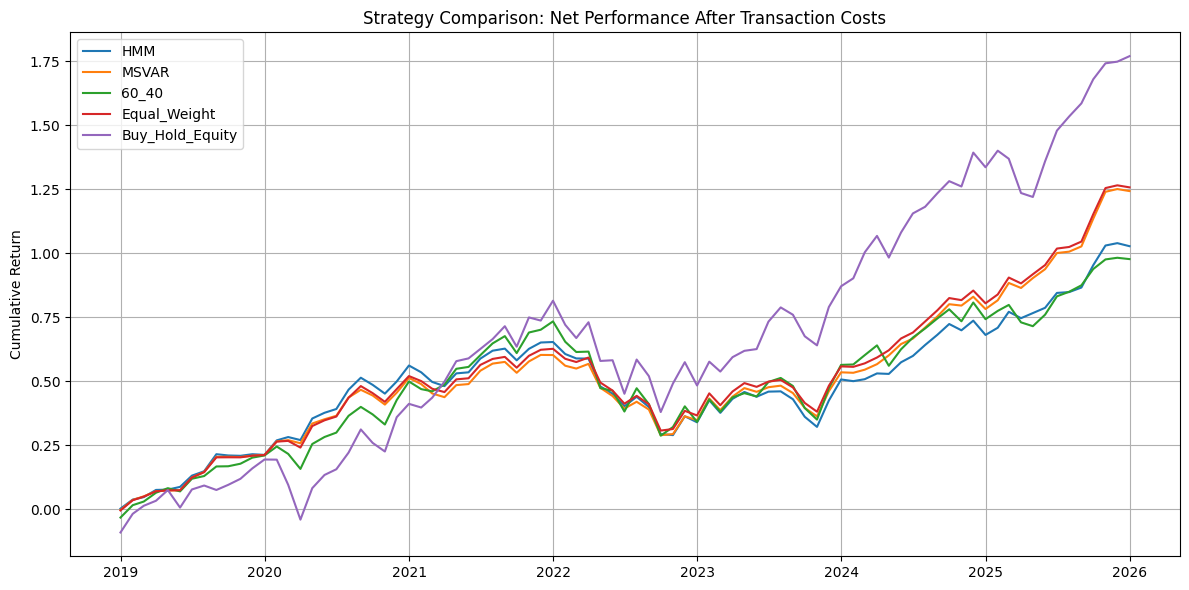

Saved figure to ..\outputs\figures\net_after_cost_strategy_comparison.png


In [10]:
net_return_series = pd.DataFrame({
    strategy_name: result["net_return_after_costs"]
    for strategy_name, result in cost_results.items()
})

net_cumulative_returns = (1 + net_return_series).cumprod() - 1

net_cumulative_returns.to_csv(
    OUTPUT_TABLES_DIR / "net_after_cost_cumulative_returns.csv"
)

plt.figure(figsize=(12, 6))

for col in net_cumulative_returns.columns:
    plt.plot(net_cumulative_returns.index, net_cumulative_returns[col], label=col)

plt.title("Strategy Comparison: Net Performance After Transaction Costs")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

output_path = OUTPUT_FIGURES_DIR / "net_after_cost_strategy_comparison.png"
plt.savefig(output_path, dpi=300)
plt.show()

print(f"Saved figure to {output_path}")

In [11]:
ranking_metrics = [
    "Annualized Return",
    "Sharpe Ratio",
    "Sortino Ratio",
    "Max Drawdown",
    "Information Ratio vs 60/40",
]

strategy_ranking = net_strategy_comparison.loc[
    [metric for metric in ranking_metrics if metric in net_strategy_comparison.index]
].T

strategy_ranking["Return Rank"] = strategy_ranking["Annualized Return"].rank(ascending=False)
strategy_ranking["Sharpe Rank"] = strategy_ranking["Sharpe Ratio"].rank(ascending=False)
strategy_ranking["Sortino Rank"] = strategy_ranking["Sortino Ratio"].rank(ascending=False)

# Max drawdown is better when it is less negative.
strategy_ranking["Drawdown Rank"] = strategy_ranking["Max Drawdown"].rank(ascending=False)

strategy_ranking = strategy_ranking.sort_values("Sharpe Rank")

strategy_ranking.to_csv(
    OUTPUT_TABLES_DIR / "net_after_cost_strategy_ranking.csv"
)

strategy_ranking

,Annualized Return,Sharpe Ratio,Sortino Ratio,Max Drawdown,Information Ratio vs 60/40,Return Rank,Sharpe Rank,Sortino Rank,Drawdown Rank
MSVAR,0.120785,1.249356,2.013955,-0.195660,0.226197,3.0,1.0,2.0,1.0
Equal_Weight,0.121807,1.242733,2.042823,-0.196336,0.260099,2.0,2.0,1.0,2.0
HMM,0.104933,1.039030,1.673645,-0.219934,0.012543,4.0,3.0,3.0,3.0
Buy_Hold_Equity,0.154681,0.936382,1.428339,-0.239596,0.683755,1.0,4.0,4.0,4.0
60_40,0.101011,0.826329,1.391770,-0.257392,NaN,5.0,5.0,5.0,5.0


## Implementation Cost Summary

The main comparison focuses on net returns after transaction costs. This section separately reports the trading activity that generated those cost adjustments.

In [12]:
implementation_cost_summary = pd.DataFrame({
    strategy_name: pd.Series({
        "Average Trade Notional": result["trade_notional"].mean(),
        "Average One-Way Turnover": result["one_way_turnover"].mean(),
        "Average Monthly Transaction Cost": result["transaction_cost"].mean(),
    })
    for strategy_name, result in cost_results.items()
})

implementation_cost_summary.to_csv(
    OUTPUT_TABLES_DIR / "implementation_cost_summary.csv"
)

implementation_cost_summary

,HMM,MSVAR,60_40,Equal_Weight,Buy_Hold_Equity
Average Trade Notional,0.037957,0.026531,0.020448,0.023722,0.0
Average One-Way Turnover,0.018978,0.013265,0.010224,0.011861,0.0
Average Monthly Transaction Cost,0.000038,0.000027,0.000020,0.000024,0.0


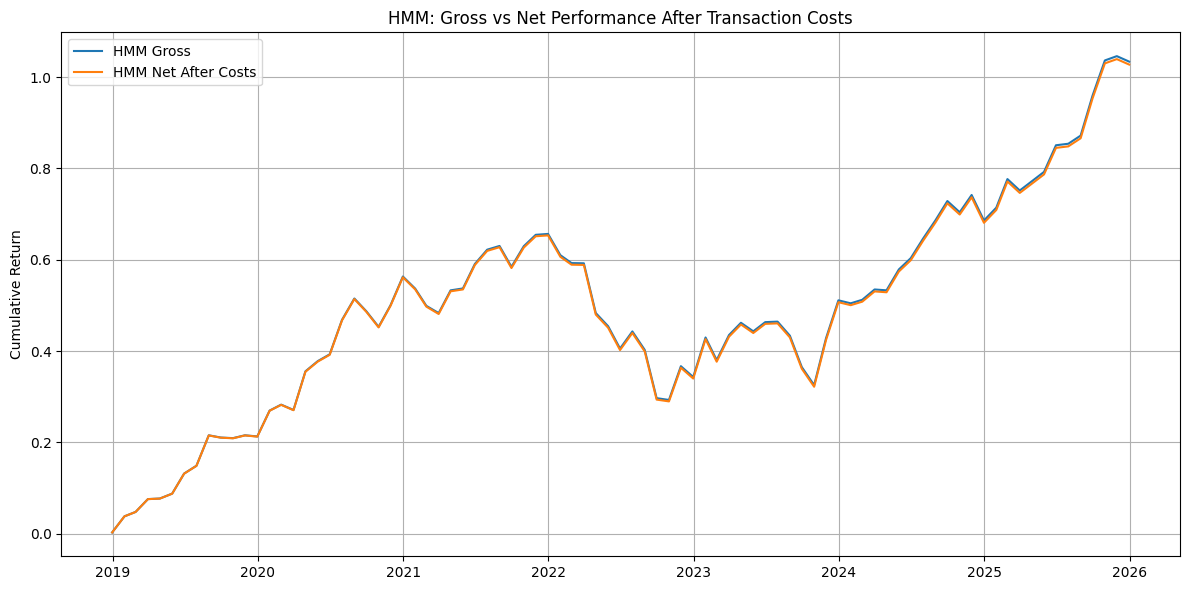

Saved figure to ..\outputs\figures\hmm_gross_vs_net_transaction_costs.png


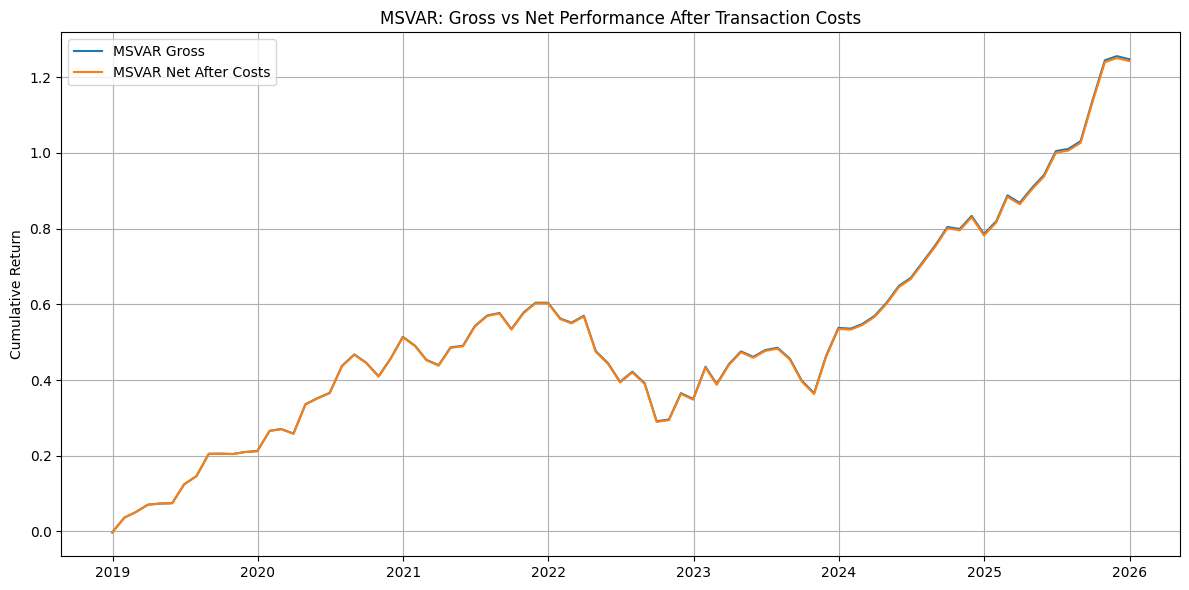

Saved figure to ..\outputs\figures\msvar_gross_vs_net_transaction_costs.png


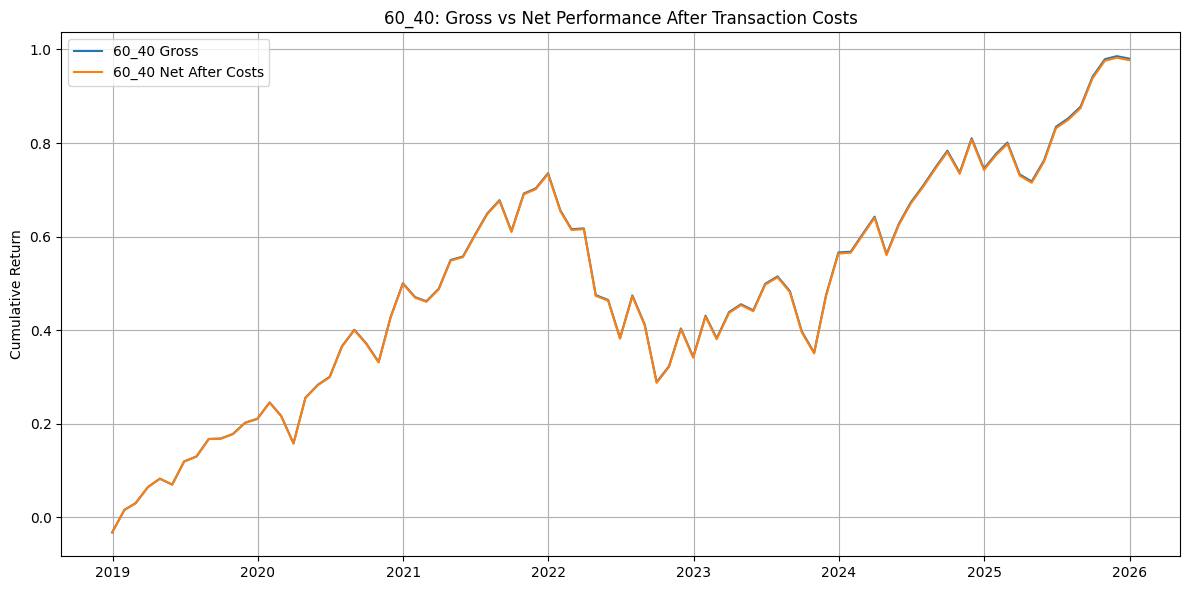

Saved figure to ..\outputs\figures\60_40_gross_vs_net_transaction_costs.png


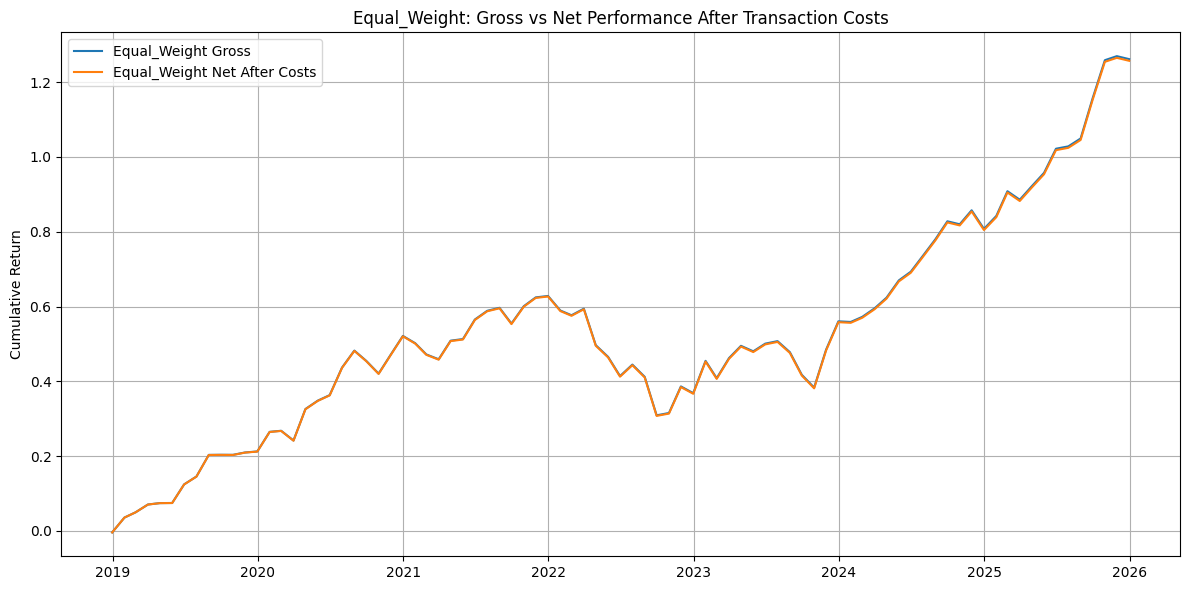

Saved figure to ..\outputs\figures\equal_weight_gross_vs_net_transaction_costs.png


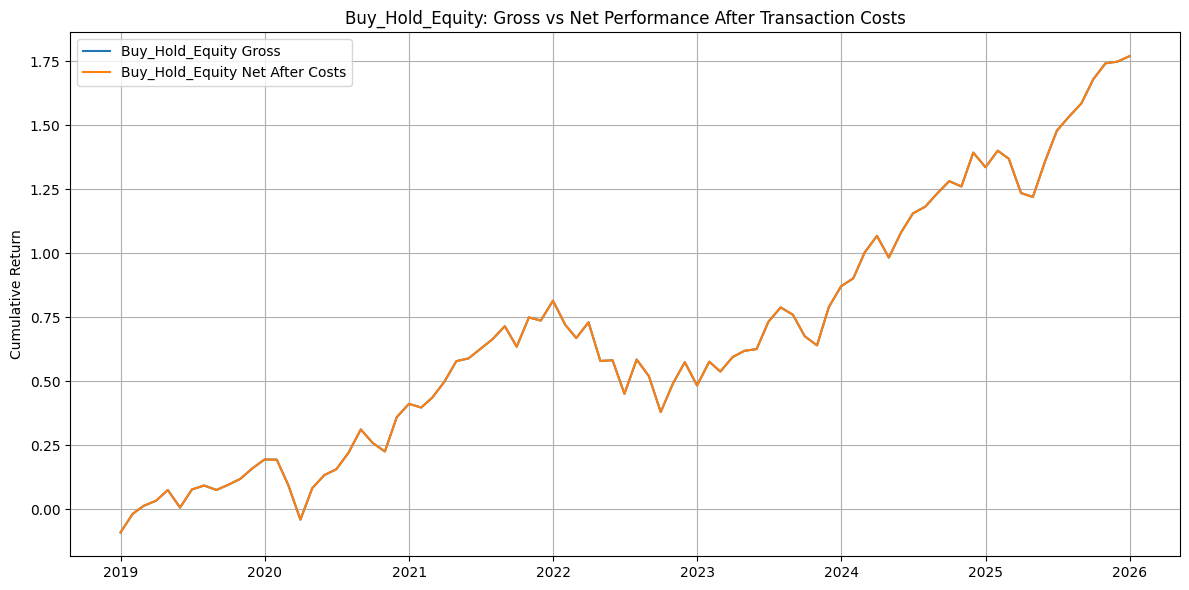

Saved figure to ..\outputs\figures\buy_hold_equity_gross_vs_net_transaction_costs.png


In [13]:
for strategy_name, result in cost_results.items():
    cumulative = (1 + result[["gross_return", "net_return_after_costs"]]).cumprod() - 1

    plt.figure(figsize=(12, 6))
    plt.plot(cumulative.index, cumulative["gross_return"], label=f"{strategy_name} Gross")
    plt.plot(cumulative.index, cumulative["net_return_after_costs"], label=f"{strategy_name} Net After Costs")

    plt.title(f"{strategy_name}: Gross vs Net Performance After Transaction Costs")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    output_path = OUTPUT_FIGURES_DIR / f"{strategy_name.lower()}_gross_vs_net_transaction_costs.png"
    plt.savefig(output_path, dpi=300)
    plt.show()

    print(f"Saved figure to {output_path}")

## Tax Sensitivity

The tax calculation is included as a sensitivity layer. It estimates potential tax drag from rebalancing sales and positive asset returns. It does not track tax lots, cost basis, holding periods, dividends, fund distributions, or investor-specific tax rates.

The purpose is to show how sensitive each strategy may be to tax drag under different assumptions, especially when strategy turnover is high.

In [14]:
def apply_asset_level_tax_sensitivity(
    target_weights,
    asset_returns,
    tax_rates,
    apply_signal_lag=True,
):
    weights = target_weights[ASSET_COLS].copy()
    returns = asset_returns[ASSET_COLS].copy()

    if apply_signal_lag:
        weights = weights.shift(1)

    weights = weights.dropna()

    common_index = weights.index.intersection(returns.index)
    weights = weights.loc[common_index]
    returns = returns.loc[common_index]

    tax_rates_series = pd.Series(tax_rates)

    records = []
    previous_target = weights.iloc[0]

    for i, date in enumerate(common_index):
        current_target = weights.loc[date]

        if i == 0:
            sell_weights = pd.Series(0.0, index=ASSET_COLS)
            prior_asset_returns = pd.Series(0.0, index=ASSET_COLS)
        else:
            previous_returns = returns.loc[common_index[i - 1]]

            drifted_weights = previous_target * (1 + previous_returns)
            drifted_weights = drifted_weights / drifted_weights.sum()

            sell_weights = (drifted_weights - current_target).clip(lower=0)
            prior_asset_returns = previous_returns

        taxable_gain_proxy = sell_weights * prior_asset_returns.clip(lower=0)
        tax_drag = (taxable_gain_proxy * tax_rates_series).sum()

        records.append({
            "Date": date,
            "tax_drag": tax_drag,
            "index_fund_sell_weight": sell_weights["index_fund"],
            "treasury_fund_sell_weight": sell_weights["treasury_fund"],
            "gold_fund_sell_weight": sell_weights["gold_fund"],
        })

        previous_target = current_target

    return pd.DataFrame(records).set_index("Date")

In [15]:
tax_results = {}

for strategy_name, weights in all_target_weights.items():
    strategy_tax_results = {}
    is_model_strategy = strategy_name in model_weights_test

    for scenario_name, tax_rates in ASSET_TAX_RATES.items():
        tax_drag = apply_asset_level_tax_sensitivity(
            target_weights=weights,
            asset_returns=asset_returns,
            tax_rates=tax_rates,
            apply_signal_lag=is_model_strategy,
        )

        base_returns = cost_results[strategy_name]["net_return_after_costs"]
        common_index = base_returns.index.intersection(tax_drag.index)

        tax_drag_aligned = tax_drag.loc[common_index, "tax_drag"].copy()

        # Exclude tax drag from the first common return observation, consistent with initial setup cost.
        tax_drag_aligned.iloc[0] = 0.0

        after_tax_returns = base_returns.loc[common_index] - tax_drag_aligned

        strategy_tax_results[scenario_name] = after_tax_returns

    tax_results[strategy_name] = pd.DataFrame(strategy_tax_results)

    output_path = OUTPUT_TABLES_DIR / f"{strategy_name.lower()}_tax_sensitivity_returns.csv"
    tax_results[strategy_name].to_csv(output_path)

    print(f"Saved {strategy_name} tax sensitivity returns to {output_path}")

Saved HMM tax sensitivity returns to ..\outputs\tables\hmm_tax_sensitivity_returns.csv
Saved MSVAR tax sensitivity returns to ..\outputs\tables\msvar_tax_sensitivity_returns.csv
Saved 60_40 tax sensitivity returns to ..\outputs\tables\60_40_tax_sensitivity_returns.csv
Saved Equal_Weight tax sensitivity returns to ..\outputs\tables\equal_weight_tax_sensitivity_returns.csv
Saved Buy_Hold_Equity tax sensitivity returns to ..\outputs\tables\buy_hold_equity_tax_sensitivity_returns.csv


In [16]:
tax_summary_blocks = []

for strategy_name, returns_df in tax_results.items():
    scenario_summaries = {}

    for scenario in returns_df.columns:
        if strategy_name == "60_40":
            scenario_benchmark = None
        else:
            scenario_benchmark = tax_results["60_40"][scenario]

        scenario_summaries[scenario] = summarize_performance(
            returns_df[scenario],
            benchmark_returns=scenario_benchmark,
        )

    tax_summary = pd.DataFrame(scenario_summaries)
    tax_summary.columns = [f"{strategy_name} - {col}" for col in tax_summary.columns]
    tax_summary_blocks.append(tax_summary)

tax_sensitivity_summary = pd.concat(tax_summary_blocks, axis=1)

tax_sensitivity_summary.to_csv(
    OUTPUT_TABLES_DIR / "tax_sensitivity_summary.csv"
)

tax_sensitivity_summary

,HMM - No Tax,HMM - Long-Term Capital Gain Sensitivity,HMM - Gold Collectibles Sensitivity,HMM - High Short-Term Sensitivity,MSVAR - No Tax,MSVAR - Long-Term Capital Gain Sensitivity,MSVAR - Gold Collectibles Sensitivity,MSVAR - High Short-Term Sensitivity,60_40 - No Tax,60_40 - Long-Term Capital Gain Sensitivity,60_40 - Gold Collectibles Sensitivity,60_40 - High Short-Term Sensitivity,Equal_Weight - No Tax,Equal_Weight - Long-Term Capital Gain Sensitivity,Equal_Weight - Gold Collectibles Sensitivity,Equal_Weight - High Short-Term Sensitivity,Buy_Hold_Equity - No Tax,Buy_Hold_Equity - Long-Term Capital Gain Sensitivity,Buy_Hold_Equity - Gold Collectibles Sensitivity,Buy_Hold_Equity - High Short-Term Sensitivity
Annualized Return,0.104933,0.103404,0.102998,0.101369,0.120785,0.119500,0.119082,0.117787,0.101011,0.099987,0.099987,0.098624,0.121807,0.120517,0.120139,0.118798,0.154681,0.154681,0.154681,0.154681
Annualized Volatility,0.101296,0.101124,0.101098,0.100901,0.095278,0.095216,0.095199,0.095136,0.126502,0.126465,0.126465,0.126418,0.096629,0.096569,0.096548,0.096493,0.169815,0.169815,0.169815,0.169815
Sharpe Ratio,1.039030,1.026844,1.023405,1.010451,1.249356,1.237951,1.234203,1.222670,0.826329,0.819126,0.819126,0.809503,1.242733,1.231416,1.228143,1.216259,0.936382,0.936382,0.936382,0.936382
Sortino Ratio,1.673645,1.651628,1.645169,1.622185,2.013955,1.984358,1.977954,1.960067,1.391770,1.378490,1.378490,1.331111,2.042823,2.005306,1.998979,1.980512,1.428339,1.428339,1.428339,1.428339
Max Drawdown,-0.219934,-0.220476,-0.220600,-0.221197,-0.195660,-0.196198,-0.196325,-0.196916,-0.257392,-0.257727,-0.257727,-0.258174,-0.196336,-0.196884,-0.197026,-0.197615,-0.239596,-0.239596,-0.239596,-0.239596
Information Ratio vs 60/40,0.012543,0.004316,-0.002209,-0.006613,0.226197,0.222662,0.216785,0.217935,NaN,NaN,NaN,NaN,0.260099,0.256239,0.250453,0.251075,0.683755,0.695706,0.695706,0.711619


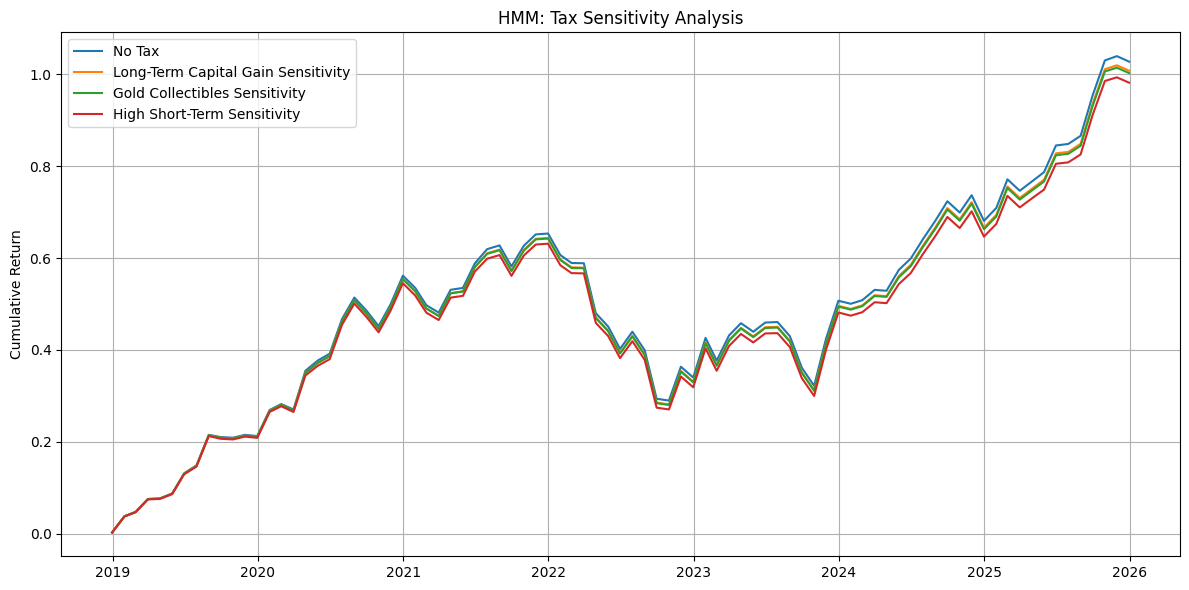

Saved figure to ..\outputs\figures\hmm_tax_sensitivity.png


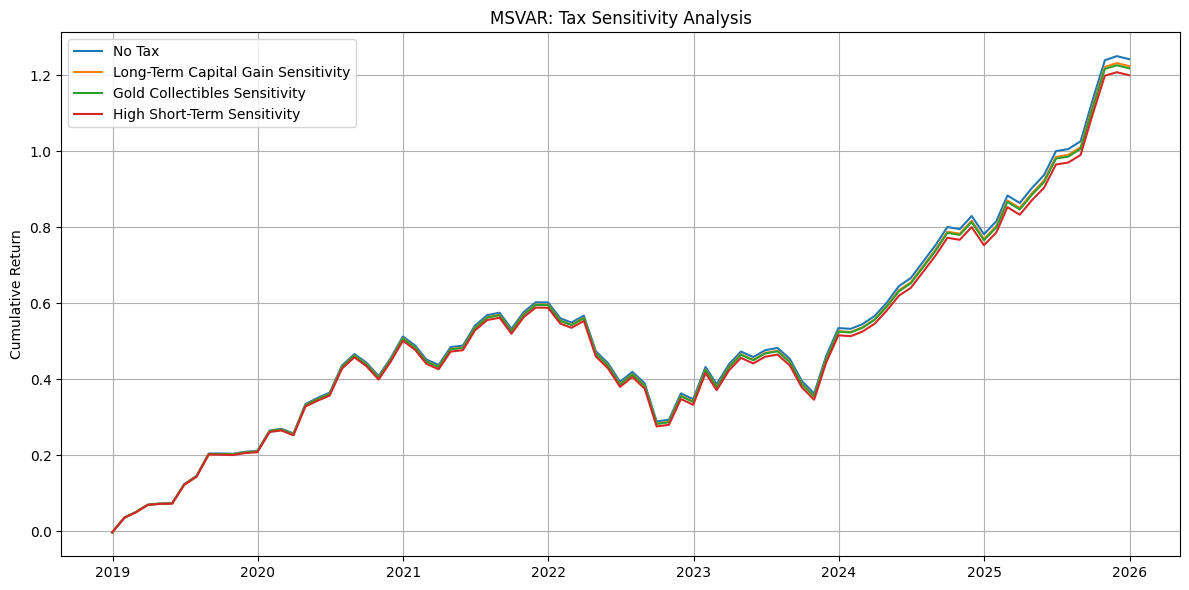

Saved figure to ..\outputs\figures\msvar_tax_sensitivity.png


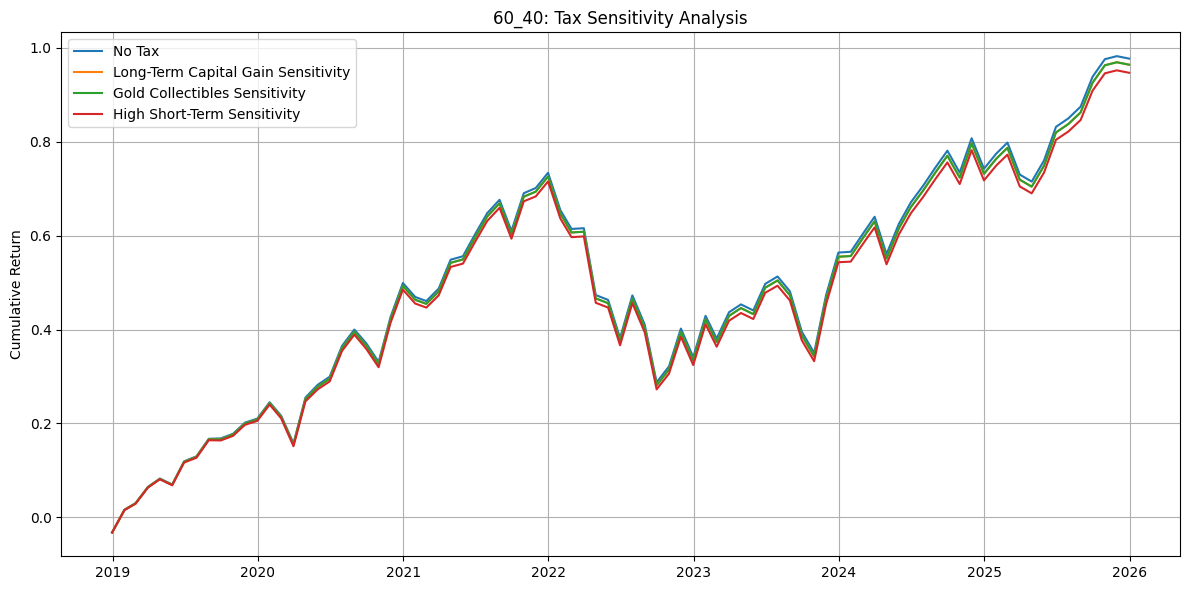

Saved figure to ..\outputs\figures\60_40_tax_sensitivity.png


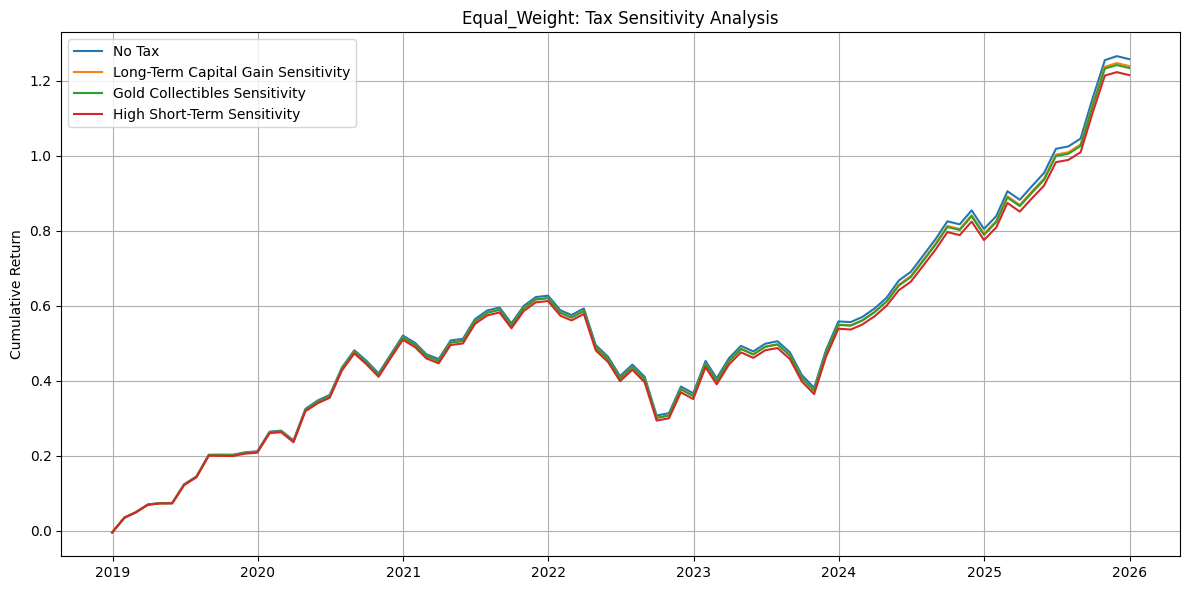

Saved figure to ..\outputs\figures\equal_weight_tax_sensitivity.png


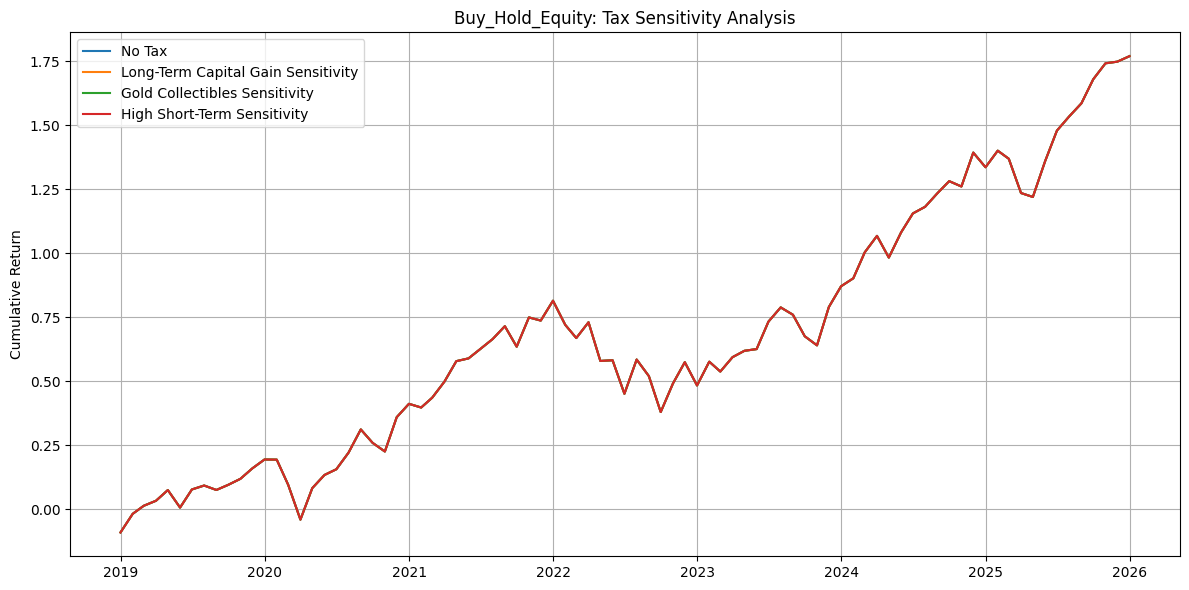

Saved figure to ..\outputs\figures\buy_hold_equity_tax_sensitivity.png


In [17]:
for strategy_name, returns_df in tax_results.items():
    cumulative = (1 + returns_df).cumprod() - 1

    plt.figure(figsize=(12, 6))

    for col in cumulative.columns:
        plt.plot(cumulative.index, cumulative[col], label=col)

    plt.title(f"{strategy_name}: Tax Sensitivity Analysis")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    output_path = OUTPUT_FIGURES_DIR / f"{strategy_name.lower()}_tax_sensitivity.png"
    plt.savefig(output_path, dpi=300)
    plt.show()

    print(f"Saved figure to {output_path}")

## Saved Outputs

The main output for the report is the net-after-cost strategy comparison over the common test period. The gross-vs-net and tax-sensitivity outputs are supporting analyses.

Primary report outputs:

- test_period_info.csv
- net_after_cost_strategy_comparison.csv
- net_after_cost_strategy_comparison.png
- net_after_cost_strategy_ranking.csv
- implementation_cost_summary.csv

Supporting outputs:

- monthly returns with costs for each strategy
- gross vs net cost-drag plots
- tax_sensitivity_summary.csv
- tax sensitivity return files and plots

## Notes for the Report

The primary comparison should use the net-after-cost strategy comparison table and cumulative return figure. These outputs compare HMM, MS-VAR, 60/40, equal-weight, and buy-and-hold equity over the common test-period return window.

The test_period_info.csv file documents the signal start dates and the realized return comparison period. This is important because HMM and MS-VAR have different test signal start dates.

The implementation cost summary explains how much trading each strategy generates. This is useful because one of the project questions is whether MS-VAR produces more stable regimes and therefore lower allocation turnover than HMM.

The tax sensitivity results should be discussed as implementation sensitivity, not as actual after-tax returns.